# 1. Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# 2. Import the dataset

In [2]:
# List the files in the folder
os.listdir()

['.ipynb_checkpoints',
 'Coffee Shop Sales.csv',
 'coffee_shop_sales_analysis.ipynb']

In [3]:
# Import the data
df = pd.read_csv('Coffee Shop Sales.csv')

In [4]:
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,30-06-2023,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,30-06-2023,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,30-06-2023,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,30-06-2023,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


# 3. Data Wrangling

In [5]:
# Show the first 5 rows in the table
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [6]:
# Check the shape of the table
df.shape

(149116, 11)

In [7]:
# Check the missing values
df.isna().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

In [8]:
# Check the duplicates
df.duplicated().sum()

0

In [9]:
# Check the datatypes
df.dtypes

transaction_id        int64
transaction_date     object
transaction_time     object
transaction_qty       int64
store_id              int64
store_location       object
product_id            int64
unit_price          float64
product_category     object
product_type         object
product_detail       object
dtype: object

In [10]:
# Check the summary statistics
df.describe()

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.542509,2.074241,17.930020,2.658723
min,1.000000,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000
max,149456.000000,8.000000,8.000000,87.000000,45.000000


# 4. Feature Engineering

In [11]:
# Make a copy of the data
data = df.copy()

In [12]:
data.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## Create new features

In [13]:
# Creating a column "transaction_timestamp" by combining transaction_date and transaction_time
data['transaction_timestamp'] = data['transaction_date'].astype(str) + ' '+ data['transaction_time'].astype(str)

In [14]:
# Converting the transaction_timestamp to datetime datatype
data['transaction_timestamp'] = pd.to_datetime(data['transaction_timestamp'],format='%d-%m-%Y %H:%M:%S')

In [15]:
data['transaction_date'] = pd.to_datetime(data['transaction_date'], format='%d-%m-%Y')

In [16]:
# Confirm that the column has been created
data.dtypes

transaction_id                    int64
transaction_date         datetime64[ns]
transaction_time                 object
transaction_qty                   int64
store_id                          int64
store_location                   object
product_id                        int64
unit_price                      float64
product_category                 object
product_type                     object
product_detail                   object
transaction_timestamp    datetime64[ns]
dtype: object

In [17]:
# Create a new column transaction_month and transaction_monthname
data['transaction_month'] = data['transaction_date'].dt.month

In [18]:
data['transaction_monthname'] = data['transaction_date'].dt.month_name()

In [19]:
# Create a new column transaction_day and transaction_dayname
data['day_of_week'] = data['transaction_date'].dt.day_of_week

In [20]:
data['day'] = data['transaction_date'].dt.day_name()

In [21]:
# Create a new column transaction_hour
data['transaction_hour'] = data['transaction_timestamp'].dt.hour

In [22]:
# Create a new column Revenue(transaction_qty * price)
data['revenue'] = data['transaction_qty'] * data['unit_price']

In [23]:
# Confirm the new columns by viewing a sample of the table
data.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_timestamp,transaction_month,transaction_monthname,day_of_week,day,transaction_hour,revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,1,January,6,Sunday,7,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:08:56,1,January,6,Sunday,7,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 07:14:04,1,January,6,Sunday,7,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 07:20:24,1,January,6,Sunday,7,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:22:41,1,January,6,Sunday,7,6.2


# 5. Data Exploration

In [24]:
# Check earliest transaction date
data['transaction_timestamp'].min()

Timestamp('2023-01-01 07:06:11')

In [25]:
# Check latest transaction date
data['transaction_timestamp'].max()

Timestamp('2023-06-30 20:57:19')

In [26]:
# Check the unique transaction hours
data['transaction_hour'].value_counts().sort_index(ascending= True)

transaction_hour
6      4594
7     13428
8     17654
9     17764
10    18545
11     9766
12     8708
13     8714
14     8933
15     8979
16     9093
17     8745
18     7498
19     6092
20      603
Name: count, dtype: int64

In [27]:
# Check the unique transaction quantities
data['transaction_qty'].value_counts()

transaction_qty
1    87159
2    58642
3     3279
4       23
8       10
6        3
Name: count, dtype: int64

In [28]:
# Check the number of stores and their locations
data['store_id'].nunique()

3

In [29]:
data['store_id'].unique()

array([5, 8, 3], dtype=int64)

In [30]:
data['store_location'].nunique()

3

In [31]:
data['store_location'].unique()

array(['Lower Manhattan', "Hell's Kitchen", 'Astoria'], dtype=object)

In [32]:
# Check the number of unique product categories
data['product_category'].nunique()

9

In [33]:
data['product_category'].unique()

array(['Coffee', 'Tea', 'Drinking Chocolate', 'Bakery', 'Flavours',
       'Loose Tea', 'Coffee beans', 'Packaged Chocolate', 'Branded'],
      dtype=object)

In [34]:
# Checking the number of products
data['product_type'].nunique()

29

In [35]:
data['product_type'].unique()

array(['Gourmet brewed coffee', 'Brewed Chai tea', 'Hot chocolate',
       'Drip coffee', 'Scone', 'Barista Espresso', 'Brewed Black tea',
       'Brewed Green tea', 'Brewed herbal tea', 'Biscotti', 'Pastry',
       'Organic brewed coffee', 'Premium brewed coffee', 'Regular syrup',
       'Herbal tea', 'Gourmet Beans', 'Organic Beans', 'Sugar free syrup',
       'Drinking Chocolate', 'Premium Beans', 'Chai tea', 'Green beans',
       'Espresso Beans', 'Green tea', 'Organic Chocolate', 'Housewares',
       'Black tea', 'House blend Beans', 'Clothing'], dtype=object)

# 6. Data Analysis

## Calculating KPI's

### Total Orders

In [36]:
# Calculate total orders
total_orders = data['transaction_id'].count()
total_orders

149116

### Total Sales

In [37]:
# Calculate total sales
total_sales = data['transaction_qty'].sum()
total_sales

214470

### No. of Worling Days

In [38]:
# Calculate total days
no_of_days = (data['transaction_date'].max() - data['transaction_date'].min()).days
no_of_days

180

### Average Order Per Day

In [39]:
# Calculate average orders per day
avg_orders_per_Day = total_orders/no_of_days
avg_orders_per_Day

828.4222222222222

### Total Revenue

In [40]:
# Calculate the total revenue
total_revenue = data['revenue'].sum()
total_revenue

698812.3300000002

### Average Order Value(AOV)

In [41]:
# Calculate average order value
aov = total_revenue/total_orders
aov

4.686367190643527

# 7. Order Analysis

### Hourly Orders

In [42]:
# Find the total orders by transaction hours
hourly_orders = data.groupby(['transaction_hour'], as_index= False).agg(total_orders = ('transaction_id', 'count'))
hourly_orders

,transaction_hour,total_orders
0,6,4594
1,7,13428
2,8,17654
3,9,17764
4,10,18545
5,11,9766
6,12,8708
7,13,8714
8,14,8933
9,15,8979


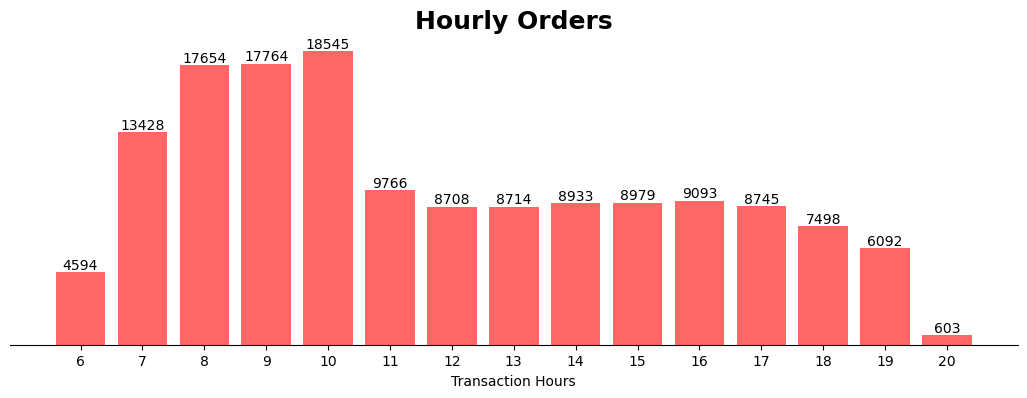

In [43]:
# Plot chart of the hourly orders
plt.figure(figsize= (13, 4))

# Add title
plt.title('Hourly Orders', fontsize=18, fontweight='bold') 

# Add x-axis label
plt.xlabel('Transaction Hours')

# Add y-axis label
plt.ylabel('Total Orders')

# Remove spines
# plt.spines[['top', 'right', 'left']].set_visible(False)
plt.gca().spines[['top', 'right', 'left']].set_visible(False)

# Remove y-axis
plt.gca().yaxis.set_visible(False)

# Add data label
for index, values in enumerate(hourly_orders['total_orders']):
    plt.annotate(values, xy= (index, values + 450), ha= 'center', va= 'center')

plt.bar(x= hourly_orders['transaction_hour'].astype('str'), height= hourly_orders['total_orders'], color= 'r', alpha= 0.6)
plt.show()

### Orders by Day of Week

In [44]:
# Calculate orders by days of the week
weekly_orders = data.groupby(['day_of_week', 'day'], as_index= False).agg(total_orders = ('transaction_id', 'count'))
weekly_orders

,day_of_week,day,total_orders
0,0,Monday,21643
1,1,Tuesday,21202
2,2,Wednesday,21310
3,3,Thursday,21654
4,4,Friday,21701
5,5,Saturday,20510
6,6,Sunday,21096


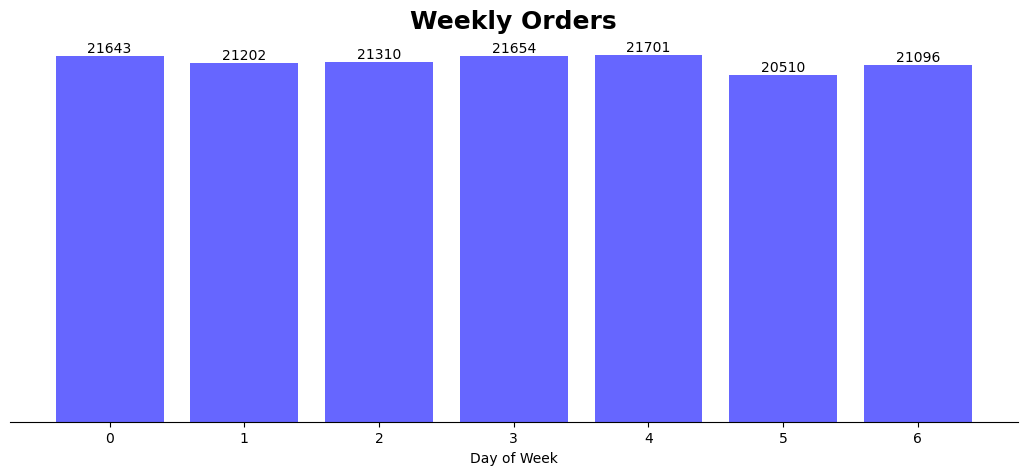

In [45]:
#Plot a bar chart of the order by day of week
plt.figure(figsize= (13, 5))

plt.bar(x= weekly_orders['day_of_week'].astype('str'), height= weekly_orders['total_orders'], color= 'b', alpha= 0.6)

# Add title
plt.title('Weekly Orders', fontsize=18, fontweight='bold') 

# Add x-axis label
plt.xlabel('Day of Week')

# Add y-axis label
plt.ylabel('Total Orders')

# Remove spines
plt.gca().spines[['top', 'right', 'left']].set_visible(False)

# Remove y-axis
plt.gca().yaxis.set_visible(False)

# Add data label
for index, values in enumerate(weekly_orders['total_orders']):
    plt.annotate(values, xy= (index, values + 450), ha= 'center', va= 'center')

plt.show()

### Order by Day of Week and Hour

In [46]:
# Plot a heat map of the orders byday of week and transaction hour
day_hour_orders = data.pivot_table(
    index= 'day_of_week',
    columns= 'transaction_hour',
    values= 'transaction_id',
    aggfunc= 'count'
)
day_hour_orders

transaction_hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
day_of_week,,,,,,,,,,,,,,,
0,661,1992,2482,2494,2612,1478,1308,1267,1376,1319,1355,1302,1077,846,74
1,489,1846,2783,2753,2846,1301,1126,1152,1224,1254,1227,1232,957,872,140
2,698,1873,2540,2527,2596,1468,1226,1311,1257,1270,1272,1235,1118,836,83
3,731,1959,2389,2375,2570,1470,1307,1317,1341,1323,1406,1311,1125,970,60
4,707,1989,2544,2707,2761,1405,1231,1199,1265,1295,1257,1226,1149,886,80
5,592,1877,2438,2345,2551,1307,1279,1187,1226,1287,1287,1178,1019,846,91
6,716,1892,2478,2563,2609,1337,1231,1281,1244,1231,1289,1261,1053,836,75


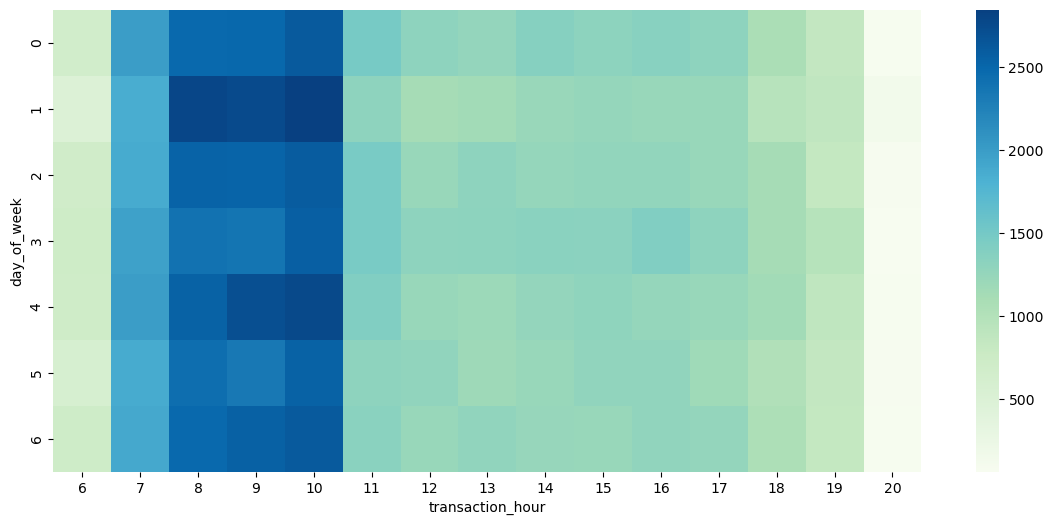

In [47]:
# Plotting a heat map
plt.figure(figsize= (14, 6))

sns.heatmap(day_hour_orders, cmap= 'GnBu')
plt.show()

### Monthly Orders

In [48]:
# Calculate the orders by month
monthly_orders = data.groupby(['transaction_month', 'transaction_monthname'], as_index= False).agg(total_orders= ('transaction_id', 'count'))
monthly_orders

,transaction_month,transaction_monthname,total_orders
0,1,January,17314
1,2,February,16359
2,3,March,21229
3,4,April,25335
4,5,May,33527
5,6,June,35352


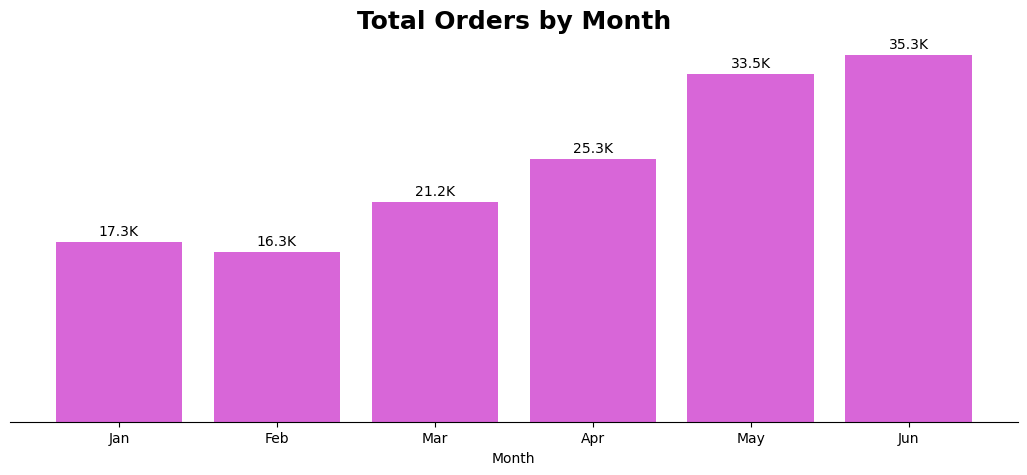

In [49]:
# Plot  a bar chart of moonthly orders
plt.figure(figsize= (13, 5))

plt.bar(x= monthly_orders['transaction_monthname'].str[0:3], height= monthly_orders['total_orders'], color= 'm', alpha= 0.6,)

# Add title
plt.title('Total Orders by Month', fontsize=18, fontweight='bold') 

# Add x-axis label
plt.xlabel('Month')

# Add y-axis label
plt.ylabel('Total Orders')

# Remove spines
# plt.spines[['top', 'right', 'left']].set_visible(False)
plt.gca().spines[['top', 'right', 'left']].set_visible(False)

# Remove y-axis
plt.gca().yaxis.set_visible(False)

# Add data annotation
for index, values in enumerate(monthly_orders['total_orders']):
    plt.annotate(str(values/1000)[0:4] + 'K', xy= (index, values + 1000), ha= 'center', va= 'center')

plt.show()

### Orders by Stores

In [50]:
# Calculate the orders by stores
store_orders = data.groupby(['store_id', 'store_location'], as_index= False).agg(total_orders= ('transaction_id', 'count')).sort_values('total_orders', ascending= False)
store_orders

,store_id,store_location,total_orders
2,8,Hell's Kitchen,50735
0,3,Astoria,50599
1,5,Lower Manhattan,47782


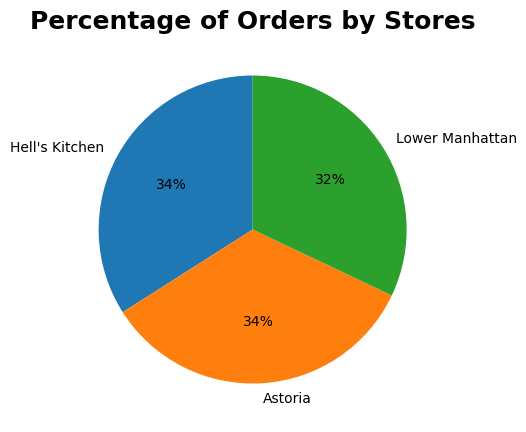

In [51]:
# Plot a pie chart oforders by stores
plt.figure(figsize= (6, 5))

plt.pie(store_orders['total_orders'], autopct= '%.0f%%', startangle= 90, labels= store_orders['store_location'])

# Add title
plt.title('Percentage of Orders by Stores', fontsize=18, fontweight='bold')
plt.show()

### Oreders by product category

In [52]:
# Calculate the orders by product category
orders_by_product_category = data.groupby(['product_category'], as_index= False).agg(total_orders= ('transaction_id', 'count')).sort_values('total_orders', ascending= False)
orders_by_product_category

,product_category,total_orders
2,Coffee,58416
8,Tea,45449
0,Bakery,22796
4,Drinking Chocolate,11468
5,Flavours,6790
3,Coffee beans,1753
6,Loose Tea,1210
1,Branded,747
7,Packaged Chocolate,487


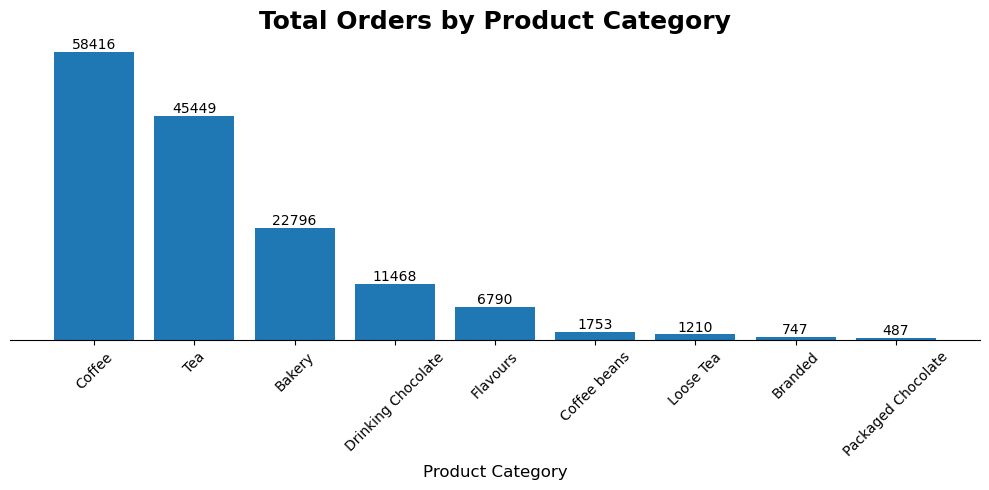

In [53]:
# Plot a bar chart
# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Bar plot
ax.bar(
    orders_by_product_category['product_category'],
    orders_by_product_category['total_orders']
)

# Title & labels
ax.set_title('Total Orders by Product Category', fontsize=18, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Total Orders', fontsize=12)

# Rotate x labels
plt.xticks(rotation=45)

# Remove unnecessary spines (clean look)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Remove y-axis ticks (optional for clean UI)
ax.yaxis.set_visible(False)

# Add value labels on bars
for i, v in enumerate(orders_by_product_category['total_orders']):
    ax.text(i, v + 500, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Top 10 Products by Orders

In [54]:
# Calculate the top 10 products by orders
products_by_orders = data.groupby(['product_type'], as_index= False).agg(total_orders= ('transaction_id', 'count')).sort_values('total_orders', ascending= False).head(10)
products_by_orders

,product_type,total_orders
4,Brewed Chai tea,17183
13,Gourmet brewed coffee,16912
0,Barista Espresso,16403
17,Hot chocolate,11468
3,Brewed Black tea,11350
6,Brewed herbal tea,11245
27,Scone,10173
22,Organic brewed coffee,8489
10,Drip coffee,8477
25,Premium brewed coffee,8135


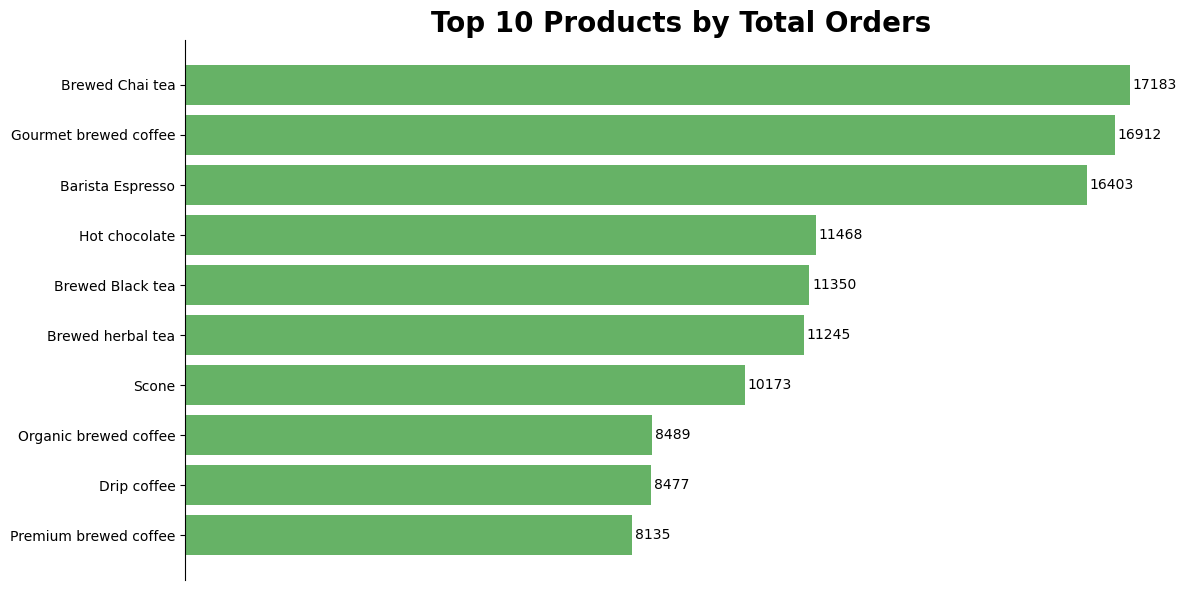

In [55]:
# Plot a bar chart
plt.figure(figsize=(12, 6))

plt.barh(products_by_orders['product_type'], products_by_orders['total_orders'], color= 'g', alpha= 0.6)

plt.gca().invert_yaxis()  # highest on top

plt.title('Top 10 Products by Total Orders', fontsize=20, fontweight='bold')

# Remove spines
for spine in ['top', 'right', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

# Remove x-axis
plt.gca().xaxis.set_visible(False)

# Add values
for i, v in enumerate(products_by_orders['total_orders']):
    plt.text(v + 50, i, str(v), va='center')

plt.tight_layout()
plt.show()

# 8. Revenue Analysis

### Monthly Revenue

In [56]:
# Calculate revenue by month
revenue_by_month = data.groupby(['transaction_month', 'transaction_monthname'], as_index= False).agg(total_revenue= ('revenue', 'sum'))
revenue_by_month

,transaction_month,transaction_monthname,total_revenue
0,1,January,81677.74
1,2,February,76145.19
2,3,March,98834.68
3,4,April,118941.08
4,5,May,156727.76
5,6,June,166485.88


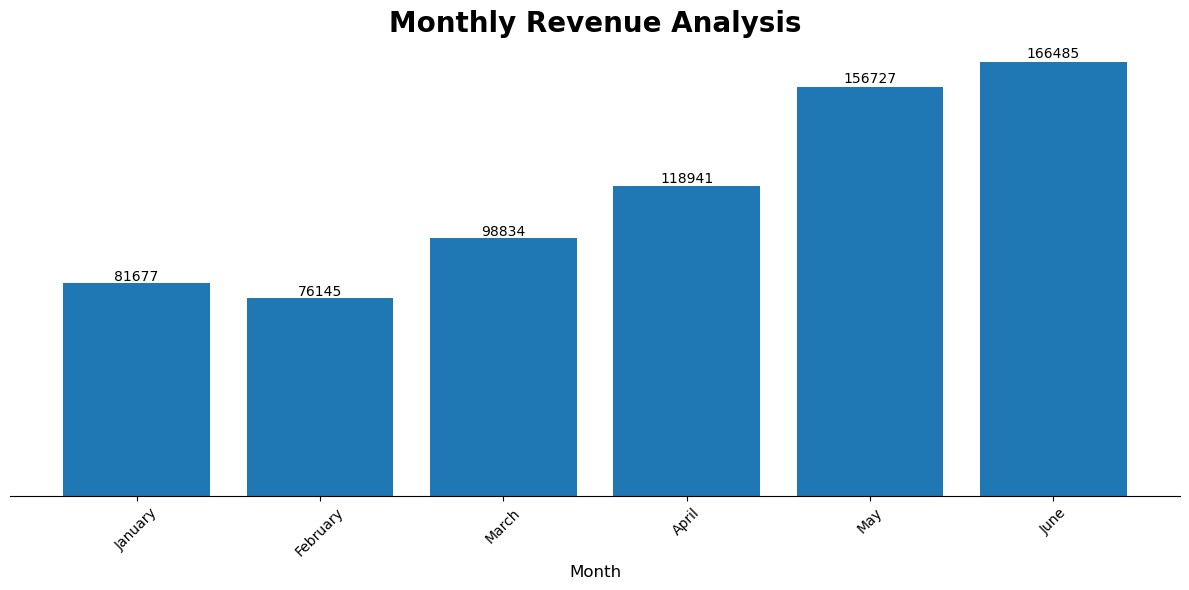

In [57]:
# Plot a bar chart
plt.figure(figsize=(12, 6))

# Bar plot
plt.bar(
    revenue_by_month['transaction_monthname'],
    revenue_by_month['total_revenue']
)

# Title & labels
plt.title('Monthly Revenue Analysis', fontsize=20, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Rotate labels
plt.xticks(rotation=45)

# Remove spines (clean look)
for spine in ['top', 'right', 'left']:
    plt.gca().spines[spine].set_visible(False)

# Remove y-axis
plt.gca().yaxis.set_visible(False)

# Add value labels
for i, v in enumerate(revenue_by_month['total_revenue']):
    plt.text(i, v + (v * 0.01), f'{int(v)}', ha='center', fontsize=10)

# Light grid (premium feel)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Revenue by Product Category

In [58]:
# Calculate revenue by product catogery
revenue_by_product_category = data.groupby(['product_category'], as_index= False).agg(total_revenue= ('revenue', 'sum')).sort_values('total_revenue', ascending= False)
revenue_by_product_category

,product_category,total_revenue
2,Coffee,269952.45
8,Tea,196405.95
0,Bakery,82315.64
4,Drinking Chocolate,72416.00
3,Coffee beans,40085.25
1,Branded,13607.00
6,Loose Tea,11213.60
5,Flavours,8408.80
7,Packaged Chocolate,4407.64


### Top 10 Products by Revenue

In [59]:
# Calculate the top 10 revenue generating products
top_products = data.groupby(['product_type'], as_index= False).agg(total_revenue= ('revenue', 'sum')).sort_values('total_revenue', ascending= False).head(10)
top_products

,product_type,total_revenue
0,Barista Espresso,91406.20
4,Brewed Chai tea,77081.95
17,Hot chocolate,72416.00
13,Gourmet brewed coffee,70034.60
3,Brewed Black tea,47932.00
6,Brewed herbal tea,47539.50
25,Premium brewed coffee,38781.15
22,Organic brewed coffee,37746.50
27,Scone,36866.12
10,Drip coffee,31984.00


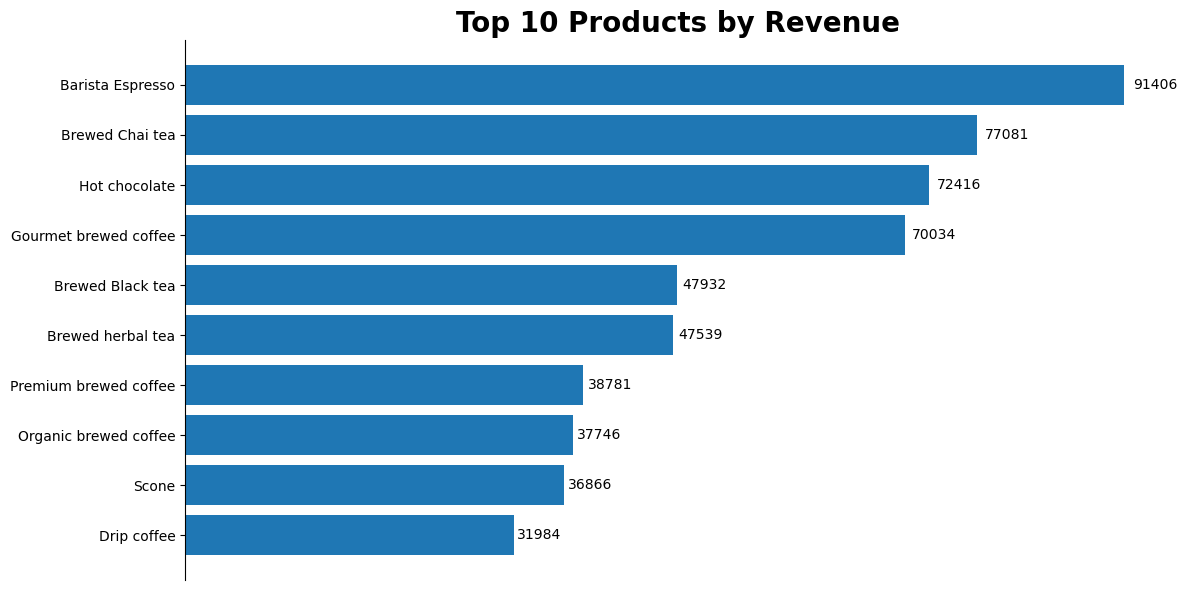

In [60]:
# Plot a bar chart
plt.figure(figsize=(12, 6))

plt.barh(
    top_products['product_type'],
    top_products['total_revenue']
)

plt.gca().invert_yaxis()

plt.title('Top 10 Products by Revenue', fontsize=20, fontweight='bold')

# Remove spines
for spine in ['top', 'right', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

# Remove x-axis
plt.gca().xaxis.set_visible(False)

# Add values
for i, v in enumerate(top_products['total_revenue']):
    plt.text(v + (v * 0.01), i, f'{int(v)}', va='center')

plt.tight_layout()
plt.show()